# DASH Quickstart

**DASH (Diversified Aggregation for Stable Hypotheses)** produces stable feature importance explanations under feature collinearity by aggregating SHAP values across a diverse ensemble of independently trained models.

This notebook demonstrates the full DASH workflow on synthetic data in under 3 minutes. By the end you will have:
- Generated correlated synthetic data with a known ground truth
- Fitted a DASH pipeline and inspected global importance
- Visualized the Importance-Stability (IS) plot
- Interpreted FSI (Feature Stability Index) scores

**Runtime:** < 3 minutes with `M=20, K=8` (paper uses `M=200, K=30`).

In [1]:
from dash_shap.core.pipeline import DASHPipeline
from dash_shap.experiments.synthetic import generate_synthetic_linear
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Generate synthetic data: N=2000 observations, P=20 features in 4 correlated groups of 5
# rho=0.9 means within-group correlation of 0.9 — a challenging collinearity scenario
(X_train, y_train, X_val, y_val, X_explain, _,
 X_test, y_test, groups, true_importance, meta) = generate_synthetic_linear(
    N=2000, P=20, group_size=5, rho=0.9, seed=42
)

print(f"Training set:   {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Explain set:    {X_explain.shape}  ← used as SHAP background (X_ref)")
print(f"Test set:       {X_test.shape}  ← held out for RMSE evaluation only")
print(f"Groups:         {groups}  ← 4 groups of 5 correlated features")

Training set:   (1199, 20)
Validation set: (300, 20)
Explain set:    (201, 20)  ← used as SHAP background (X_ref)
Test set:       (300, 20)  ← held out for RMSE evaluation only
Groups:         [0 0 0 0 0 1 1 1 1 1 2 2 2 2 2 3 3 3 3 3]  ← 4 groups of 5 correlated features


## The Four-Way Data Split

DASH uses four separate data splits to avoid data leakage:

| Split | Variable | Purpose |
|---|---|---|
| Train | `X_train` | XGBoost model fitting |
| Validation | `X_val` | Model scoring and epsilon filter |
| Explain | `X_explain` / `X_ref` | SHAP background — **must be held out from training** |
| Test | `X_test` | Final RMSE evaluation only — never seen during fitting |

**Why separate `X_explain` from `X_test`?** The SHAP background (`X_ref`) is used to compute attributions for every selected model. If it overlapped with `X_test`, importance values would be computed on data that also measures the pipeline's final performance — a subtle form of data leakage. Keeping them separate ensures SHAP attributions and RMSE are independent.

In [3]:
# Fit DASH pipeline
# M=20, K=8 for speed — paper uses M=200, K=30
pipe = DASHPipeline(
    M=20,           # Population size: train 20 diverse XGBoost models
    K=8,            # Select 8 most diverse models for consensus
    epsilon=0.10,   # Keep models within 10% R² of the best model
    seed=42,
    verbose=True,
)
pipe.fit(X_train, y_train, X_val, y_val, X_ref=X_explain)

DASH Stage 1: Population Generation
Training 20 models with -1 parallel jobs...


Training: 100%|██████████| 20/20 [00:00<00:00, 2307.03it/s]


Population trained. Best: -0.5709, Worst: -0.7267, Mean: -0.6274

DASH Stage 2: Performance Filtering (epsilon=0.1)
Performance filter (absolute): 16/20 models within epsilon=0.1 of best (-0.5709)

DASH Stage 3: Diversity Selection (maxmin)
  Diversity threshold reached at K=7 (min_dist=0.0462 < delta=0.05)
MaxMin selection: 7 models selected from 16 candidates

DASH Stage 4: Consensus SHAP (K=7)
Computing SHAP for 7 models with n_jobs=-1...
Consensus computed from 7 models. Top 5 features: [0, 3, 1, 2, 8]

DASH Stage 5: Stability Diagnostics

Pipeline complete in 17.0s (Training: 6.3s, SHAP: 10.7s)


In [4]:
# Global feature importance — mean absolute SHAP value per feature
print(f"Shape of global_importance_: {pipe.global_importance_.shape}")
print()

# Top-5 features by importance
ranking = pipe.get_importance_ranking()
print("Top 5 features by DASH importance:")
for rank, feat_idx in enumerate(ranking[:5]):
    print(f"  {rank+1}. f{feat_idx}: importance={pipe.global_importance_[feat_idx]:.4f}")

print()
print("True group structure (features in same group share importance):")
for g_idx, g in enumerate(groups):
    print(f"  Group {g_idx}: features {g}")

Shape of global_importance_: (20,)

Top 5 features by DASH importance:
  1. f0: importance=0.3347
  2. f3: importance=0.3288
  3. f1: importance=0.3277
  4. f2: importance=0.3039
  5. f8: importance=0.2458

True group structure (features in same group share importance):
  Group 0: features 0
  Group 1: features 0
  Group 2: features 0
  Group 3: features 0
  Group 4: features 0
  Group 5: features 1
  Group 6: features 1
  Group 7: features 1
  Group 8: features 1
  Group 9: features 1
  Group 10: features 2
  Group 11: features 2
  Group 12: features 2
  Group 13: features 2
  Group 14: features 2
  Group 15: features 3
  Group 16: features 3
  Group 17: features 3
  Group 18: features 3
  Group 19: features 3


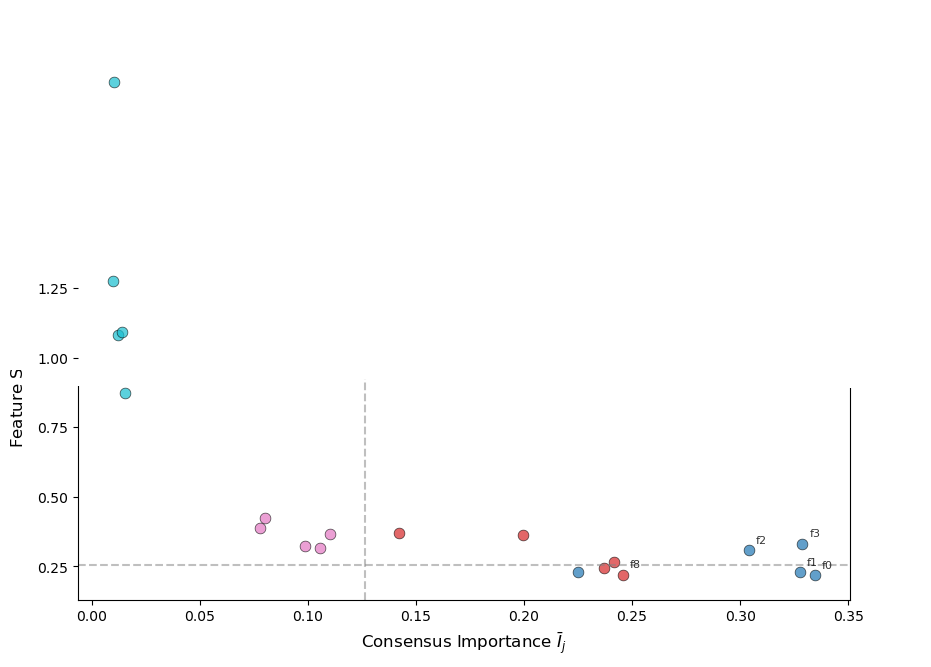

In [5]:
# Importance-Stability (IS) Plot
# Each point is a feature. X-axis: global importance. Y-axis: FSI (instability).
# Quadrant IV (high importance, low FSI) = Robust features — most trustworthy.
# Quadrant I (high importance, high FSI) = Collinear group members — interpret as a group.
fig = pipe.plot_importance_stability(groups=groups)
plt.tight_layout()
plt.show()

## Interpreting FSI

The **Feature Stability Index (FSI)** measures how much a feature's SHAP attribution varies across the K selected models.

- **FSI = 0**: perfectly stable — all K models agree on this feature's importance
- **High FSI**: attribution is inconsistent — the feature is likely collinear with others

The IS plot divides features into four quadrants:

| Quadrant | Importance | FSI | What to do |
|---|---|---|---|
| **IV** (bottom-right) | High | Low | **Trust it** — robust, stable attribution |
| **I** (top-right) | High | High | Report the *group*, not the individual feature |
| **III** (bottom-left) | Low | Low | Confidently unimportant |
| **II** (top-left) | Low | High | Unstable noise — de-emphasize |

In [6]:
# FSI summary table
fsi = pipe.get_fsi()
print(fsi.summary(top_k=10))

print()
# Quadrant labels for each feature
labels = fsi.get_quadrant_labels()
robust = [f for f, l in zip(fsi.feature_names, labels) if 'Robust' in l]
collinear = [f for f, l in zip(fsi.feature_names, labels) if 'Collinear' in l or 'Quadrant I' in l]
print(f"Robust features (high importance, low FSI): {robust}")
print(f"Collinear features (high importance, high FSI): {collinear}")

Feature Stability Summary
Feature                Importance      FSI
----------------------------------------
f0                         0.3347    0.218
f3                         0.3288    0.332
f1                         0.3277    0.229
f2                         0.3039    0.309
f8                         0.2458    0.221
f9                         0.2415    0.265
f7                         0.2371    0.244
f4                         0.2252    0.229
f5                         0.1997    0.362
f6                         0.1423    0.372

Robust features (high importance, low FSI): ['f0', 'f1', 'f4', 'f7', 'f8']
Collinear features (high importance, high FSI): ['f2', 'f3', 'f5', 'f6', 'f9']


## Going Further: Extensions Framework

The IS-plot tells you *which quadrant* each feature falls into.
The **extensions framework** lets you act on that classification:

- **`robust_certification`** — gives a worst-case guarantee: which features are *always* in the top-k across every model in the ensemble?
- **`confidence_intervals`** — quantifies how precisely DASH knows each feature's importance and rank.

In [7]:
# Extension 9: Robust Certification
# A feature is "certified top-k" if it ranks in the top-k across EVERY one of the K selected models.
# This is a worst-case guarantee — not just the consensus average.
from dash_shap.extensions import robust_certification

cert = robust_certification(pipe.result_)
print(cert.summary())
print()
print("Interpretation:")
print("  Certified top-3 = this feature is definitively important (not just on average)")
print("  Uncertified     = its ranking varies across models (may be collinear with another feature)")

CertificationResult: P=20, K-values tested=[1, 2, 3, 5, 10]

  Certified top-1: (none)
  Certified top-2: (none)
  Certified top-3: (none)
  Certified top-5: ['f0']
  Certified top-10: ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f7', 'f8', 'f9']

Max ranks (worst-case across K models):
  f0: max_rank=5
  f1: max_rank=7
  f2: max_rank=9
  f3: max_rank=8
  f4: max_rank=10
  f5: max_rank=10
  f6: max_rank=13
  f7: max_rank=9
  f8: max_rank=8
  f9: max_rank=9
  f10: max_rank=14
  f11: max_rank=14
  f12: max_rank=15
  f13: max_rank=15
  f14: max_rank=15
  f15: max_rank=19
  f16: max_rank=20
  f17: max_rank=20
  f18: max_rank=20
  f19: max_rank=20

Interpretation:
  Certified top-3 = this feature is definitively important (not just on average)
  Uncertified     = its ranking varies across models (may be collinear with another feature)


In [8]:
# Extension 1: Confidence Intervals
# How precisely does DASH know the top feature's importance?
# Wide CI = attribution is uncertain across models. Narrow CI = robust estimate.
from dash_shap.extensions import confidence_intervals

ci = confidence_intervals(pipe.result_, alpha=0.05, n_boot=500)

top_feat_idx = int(np.argmax(pipe.global_importance_))
top_feat_name = pipe.feature_names_[top_feat_idx]
lo, pt, hi = ci.importance_ci[top_feat_idx]
print(f"Top feature '{top_feat_name}':")
print(f"  Importance: {pt:.4f} (95% CI: [{lo:.4f}, {hi:.4f}])")
print()

# Show CI width per feature — narrow = confident, wide = uncertain
widths = ci.importance_ci[:, 2] - ci.importance_ci[:, 0]
most_uncertain = pipe.feature_names_[int(np.argmax(widths))]
print(f"Most uncertain feature: '{most_uncertain}' (CI width = {widths.max():.4f})")
print("  → Wide CI often indicates collinearity: credit shared with a correlated feature")

Top feature 'f0':
  Importance: 0.3347 (95% CI: [0.2975, 0.3799])

Most uncertain feature: 'f3' (CI width = 0.1315)
  → Wide CI often indicates collinearity: credit shared with a correlated feature
